In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [22]:
def histogram(file1, skip1, file2, skip2, pl_orbper_min1, pl_orbper_max1, pl_orbper_min2, pl_orbper_max2, rad_min1, rad_max1, rad_min2, rad_max2):
    df_combined1 = pd.DataFrame()
    df_combined2 = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df1 = pd.read_csv(file1, skiprows=skip1)
    df2 = pd.read_csv(file2, skiprows=skip2)

    if 'Orbital Period (days)' in df1.columns:
        df1.rename(columns={'Orbital Period (days)': 'pl_orbper'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df1.columns:
        df1.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    if 'Orbital Period (days)' in df2.columns:
        df2.rename(columns={'Orbital Period (days)': 'pl_orbper'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df2.columns:
        df2.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    df1 = df1.dropna(subset=['pl_orbper', 'pl_rade'])
    df1 = df1[(df1['pl_orbper'] < pl_orbper_max1) & (df1['pl_orbper'] > pl_orbper_min1)]
    df1 = df1[(df1['pl_rade'] < rad_max1) & (df1['pl_rade'] > rad_min1)]
    df1 = df1[(df1['st_teff'] < 3500) & (df1['st_teff'] > 3000)]


    df2 = df2.dropna(subset=['pl_orbper', 'pl_rade'])
    df2 = df2[(df2['pl_orbper'] < pl_orbper_max2) & (df2['pl_orbper'] > pl_orbper_min2)]
    df2 = df2[(df2['pl_rade'] < rad_max2) & (df2['pl_rade'] > rad_min2)]
    df2 = df2[(df2['st_teff'] < 4000) & (df2['st_teff'] > 3500)]


    if 'tfopwg_disp' in df1.columns:
        df1 = df1[df1['tfopwg_disp'] != 'FP']
    if 'tfopwg_disp' in df2.columns:
        df2 = df2[df2['tfopwg_disp'] != 'FP']

    df_combined1 = pd.concat([df_combined1, df1], ignore_index=True)
    df_combined2 = pd.concat([df_combined2, df2], ignore_index=True)

    plt.scatter(df1['pl_rade'], df1['pl_orbper'], alpha=0.5, label=f'{file1}')
    plt.scatter(df2['pl_rade'], df2['pl_orbper'], alpha=0.5, label=f'{file2}')
    if 'pl_name' in df1.columns:
        for i, txt in enumerate(df1['pl_name']):
            plt.annotate(txt, (df1['pl_rade'].iloc[i], df1['pl_orbper'].iloc[i]), fontsize=8, alpha=0.7)
    if 'pl_name' in df2.columns:
        for i, txt in enumerate(df2['pl_name']):
            plt.annotate(txt, (df2['pl_rade'].iloc[i], df2['pl_orbper'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined1 = df_combined1[df_combined1['pl_name'].isnull() | ~df_combined1[df_combined1['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
        df_combined2 = df_combined2[df_combined2['pl_name'].isnull() | ~df_combined2[df_combined2['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined1.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)
    df_combined2.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    plt.title('Planetary Radius vs Orbital Period')
    plt.ylabel('Orbital Period (days)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(10, 6))

    df1['pl_rade'] = df1['pl_rade']
    plt.hist(df1['pl_rade'], alpha=0.5, label=f'{file1} {pl_orbper_min1}-{pl_orbper_max1} days')
    plt.hist(df2['pl_rade'], alpha=0.5, label=f'{file2} {pl_orbper_min2}-{pl_orbper_max2} days')
    
    mean1 = df1['pl_rade'].mean()
    mean2 = df2['pl_rade'].mean()
    median1 = df1['pl_rade'].median()
    median2 = df2['pl_rade'].median()

    plt.axvline(mean1, color='blue', linestyle='-', linewidth=1, label=f'{file1} mean, {pl_orbper_min1}-{pl_orbper_max1} days')
    plt.text(mean1, plt.ylim()[1] * 0.9, f'{mean1:.2f}', color='blue', fontsize=8, rotation=90, verticalalignment='center')

    plt.axvline(mean2, color='chocolate', linestyle='-', linewidth=1, label=f'{file2} mean, {pl_orbper_min2}-{pl_orbper_max2} days')
    plt.text(mean2, plt.ylim()[1] * 0.9, f'{mean2:.2f}', color='chocolate', fontsize=8, rotation=90, verticalalignment='center')

    plt.axvline(median1, color='midnightblue', linestyle='dashed', linewidth=1, label=f'{file1} median, {pl_orbper_min1}-{pl_orbper_max1} days')
    plt.text(median1, plt.ylim()[1] * 0.8, f'{median1:.2f}', color='midnightblue', fontsize=8, rotation=90, verticalalignment='center')

    plt.axvline(median2, color='saddlebrown', linestyle='dashed', linewidth=1, label=f'{file2} median, {pl_orbper_min2}-{pl_orbper_max2} days')
    plt.text(median2, plt.ylim()[1] * 0.8, f'{median2:.2f}', color='saddlebrown', fontsize=8, rotation=90, verticalalignment='center')

    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Planetary Radius')
    plt.legend()
    plt.grid(True)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.hist(df1['pl_rade'], bins=len(df1['pl_rade'])*3, alpha=0.5, label=f'{file1}, {pl_orbper_min1}-{pl_orbper_max1} days', cumulative=True, histtype='step', density=True)
    ax1.hist(df2['pl_rade'], bins=len(df2['pl_rade'])*3, alpha=0.5, label=f'{file2}, {pl_orbper_min2}-{pl_orbper_max2} days', cumulative=True, histtype='step', density=True)

    ax1.set_xlabel('Planetary Radius (Earth Radii)')
    ax1.set_ylabel('Cumulative Frequency')
    ax1.set_title('Cumulative Distribution of Planetary Radius')
    ax1.legend()
    ax1.grid(True)

    plt.show()


KeyError: 'pl_name'


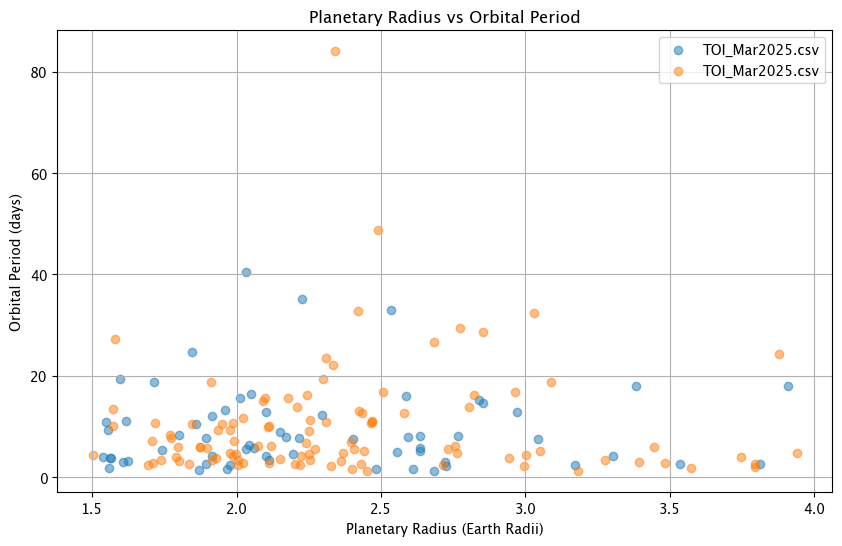

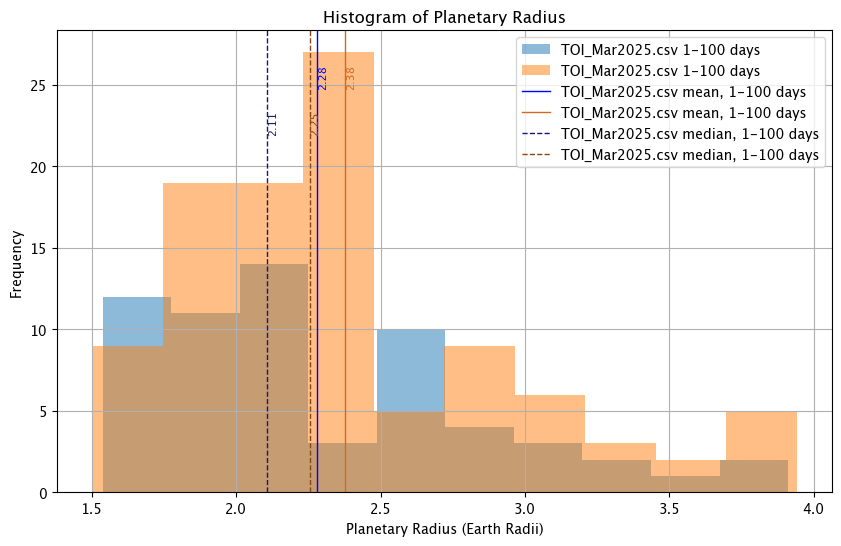

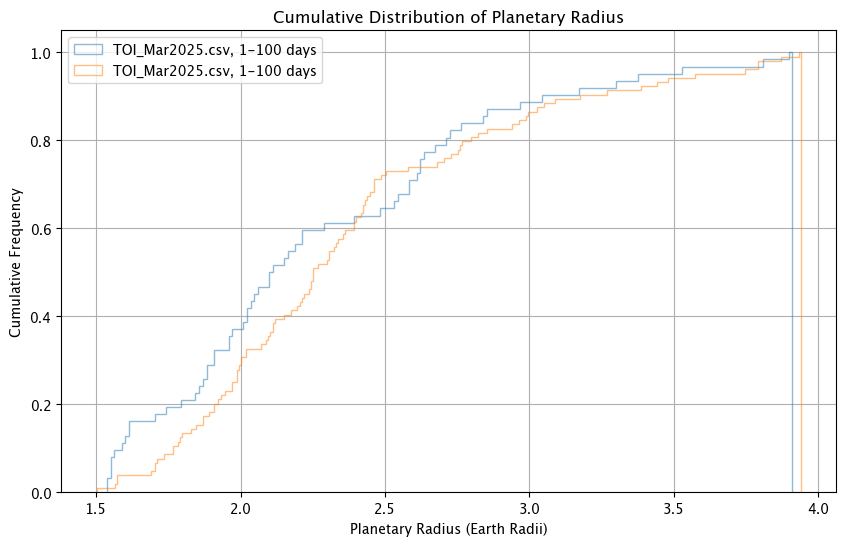

In [26]:
# Define the ranges for orbital period and planetary radius
pl_orbper_min1_range = (1, 1)
pl_orbper_max1_range = (100, 100)
pl_orbper_min2_range = (1, 1)
pl_orbper_max2_range = (100, 100)
rad_min1_range = (1.5, 4)
rad_max1_range = (4, 4.1)
rad_min2_range = (1.5, 4)
rad_max2_range = (4, 4.1)

# Assign the first value of each range to the corresponding variable
pl_orbper_min1 = pl_orbper_min1_range[0]
pl_orbper_max1 = pl_orbper_max1_range[0]
pl_orbper_min2 = pl_orbper_min2_range[0]
pl_orbper_max2 = pl_orbper_max2_range[0]
rad_min1 = rad_min1_range[0]
rad_max1 = rad_max1_range[0]
rad_min2 = rad_min2_range[0]
rad_max2 = rad_max2_range[0]

# Call the histogram function with the updated variables
histogram('TOI_Mar2025.csv', 71, 'TOI_Mar2025.csv', 71, pl_orbper_min1, pl_orbper_max1, pl_orbper_min2, pl_orbper_max2, rad_min1, rad_max1, rad_min2, rad_max2)
